In [1]:
!pip install qiskit qiskit-aer matplotlib ipywidgets



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

from IPython.display import display, clear_output

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, plot_bloch_multivector

print("Qiskit application environment ready!")

Qiskit application environment ready!


In [3]:
qc = QuantumCircuit(2, 2)

print(qc)

     
q_0: 
     
q_1: 
     
c: 2/
     


In [4]:
print("Number of qubits:", qc.num_qubits)
print("Number of classical bits:", qc.num_clbits)

Number of qubits: 2
Number of classical bits: 2


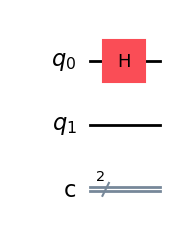

In [8]:
from IPython.display import display

display(qc.draw("mpl"))

In [9]:
qc.draw("mpl")
plt.show()

In [10]:
state = Statevector.from_instruction(qc)

print(state)

Statevector([0.70710678+0.j, 0.70710678+0.j, 0.        +0.j,
             0.        +0.j],
            dims=(2, 2))


In [11]:
print(state.draw("text"))

[0.70710678+0.j,0.70710678+0.j,0.        +0.j,0.        +0.j]


In [12]:
probabilities = state.probabilities_dict()

print(probabilities)

{np.str_('00'): np.float64(0.4999999999999999), np.str_('01'): np.float64(0.4999999999999999)}


In [13]:
plot_bloch_multivector(state)
plt.show()

In [14]:
print("Quantum State:")
print(state.draw("text"))

print("\nProbabilities:")
for basis_state, probability in state.probabilities_dict().items():
    print(f"{basis_state}: {probability * 100:.1f}%")

Quantum State:
[0.70710678+0.j,0.70710678+0.j,0.        +0.j,0.        +0.j]

Probabilities:
00: 50.0%
01: 50.0%


In [15]:
plot_bloch_multivector(state)
plt.show()

In [16]:
bell = QuantumCircuit(2, 2)

bell.h(0)
bell.cx(0, 1)

print(bell)

     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
c: 2/══════════
               


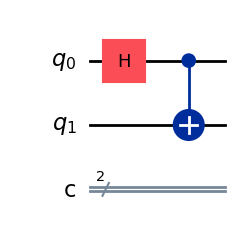

In [17]:
from IPython.display import display

display(bell.draw("mpl"))

In [18]:
bell_state = Statevector.from_instruction(bell)

print(bell_state)

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


In [19]:
bell_probabilities = bell_state.probabilities_dict()

print(bell_probabilities)

{np.str_('00'): np.float64(0.4999999999999999), np.str_('11'): np.float64(0.4999999999999999)}


In [20]:
plot_bloch_multivector(bell_state)
plt.show()

In [21]:
bell_measure = QuantumCircuit(2, 2)

bell_measure.h(0)
bell_measure.cx(0, 1)

bell_measure.measure([0, 1], [0, 1])

print(bell_measure)

     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 


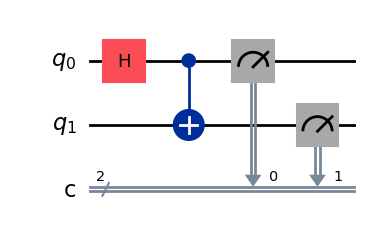

In [22]:
from IPython.display import display

display(bell_measure.draw("mpl"))

In [23]:
simulator = AerSimulator()

print("Simulator created successfully!")

Simulator created successfully!


In [24]:
plot_histogram(counts)
plt.show()

NameError: name 'counts' is not defined

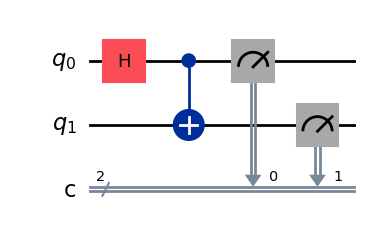

Measurement Results:
{'00': 517, '11': 507}


In [25]:
# Create the measured Bell circuit
bell_measure = QuantumCircuit(2, 2)

bell_measure.h(0)
bell_measure.cx(0, 1)

# Measure both qubits
bell_measure.measure([0, 1], [0, 1])

# Display the circuit
display(bell_measure.draw("mpl"))

# Create simulator
simulator = AerSimulator()

# Run simulation with 1024 shots
result = simulator.run(
    bell_measure,
    shots=1024
).result()

# Get measurement counts
counts = result.get_counts()

# Display results
print("Measurement Results:")
print(counts)

In [26]:
plot_histogram(counts)
plt.show()

In [27]:
total_shots = sum(counts.values())

print("Measurement Results")
print("-------------------")

for state_value, count in counts.items():
    percentage = (count / total_shots) * 100
    print(f"{state_value}: {count} shots ({percentage:.2f}%)")

print("-------------------")
print("Total shots:", total_shots)

Measurement Results
-------------------
00: 517 shots (50.49%)
11: 507 shots (49.51%)
-------------------
Total shots: 1024


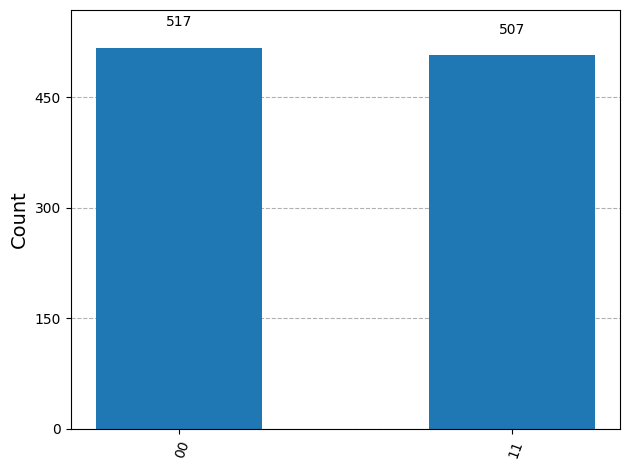

In [28]:
fig = plot_histogram(counts)
display(fig)

In [29]:
%matplotlib inline

import matplotlib.pyplot as plt
from IPython.display import display

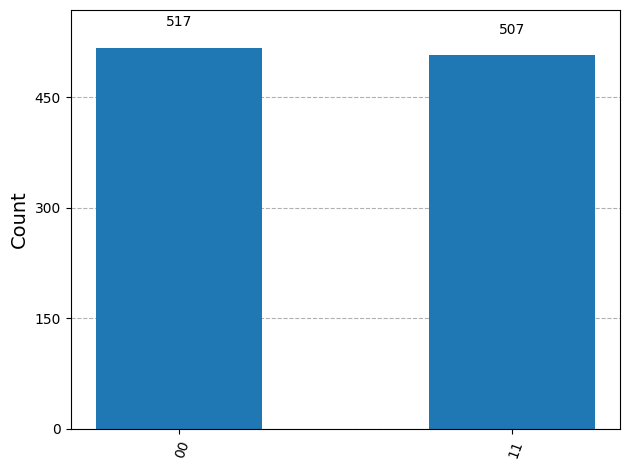

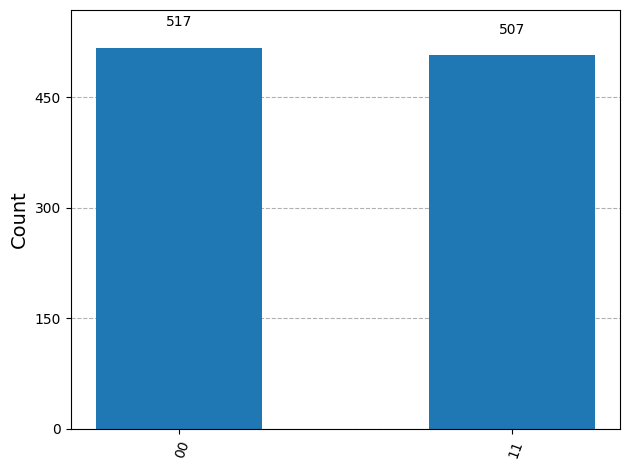

In [30]:
fig = plot_histogram(counts)
display(fig)

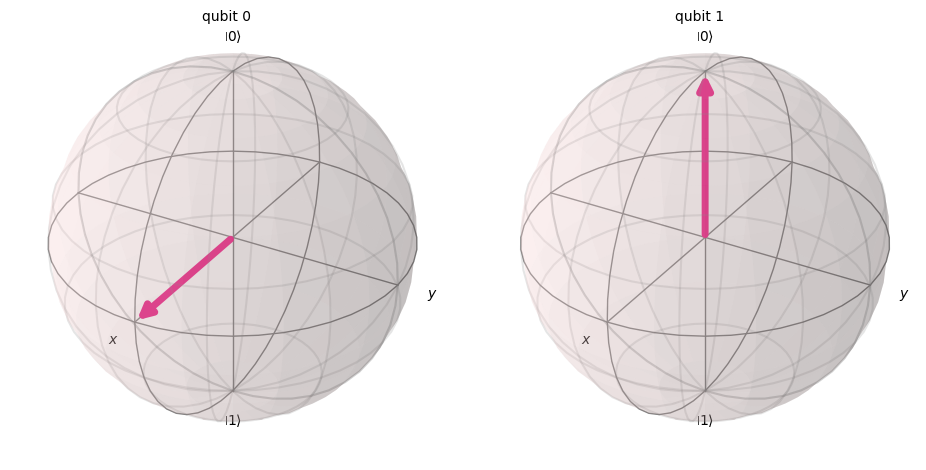

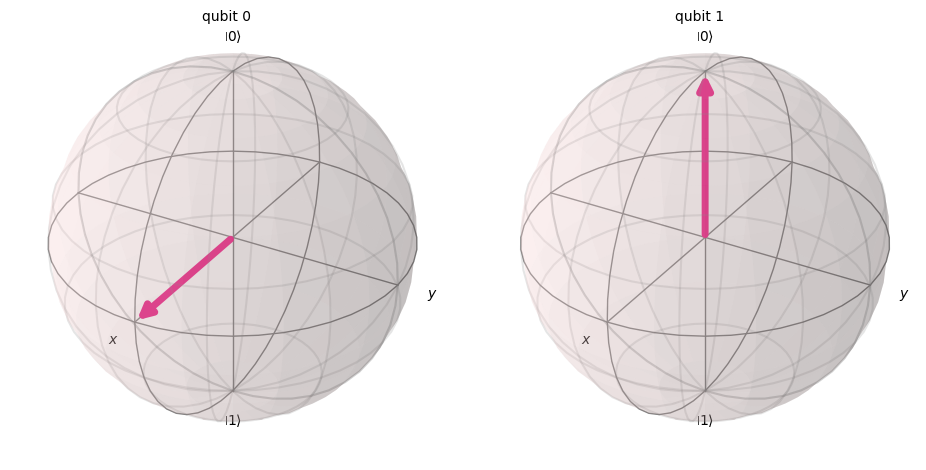

In [31]:
fig = plot_bloch_multivector(state)
display(fig)

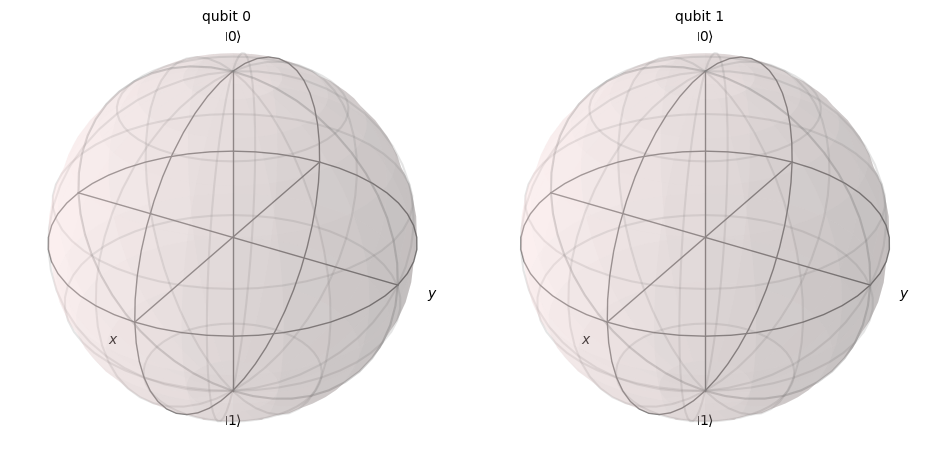

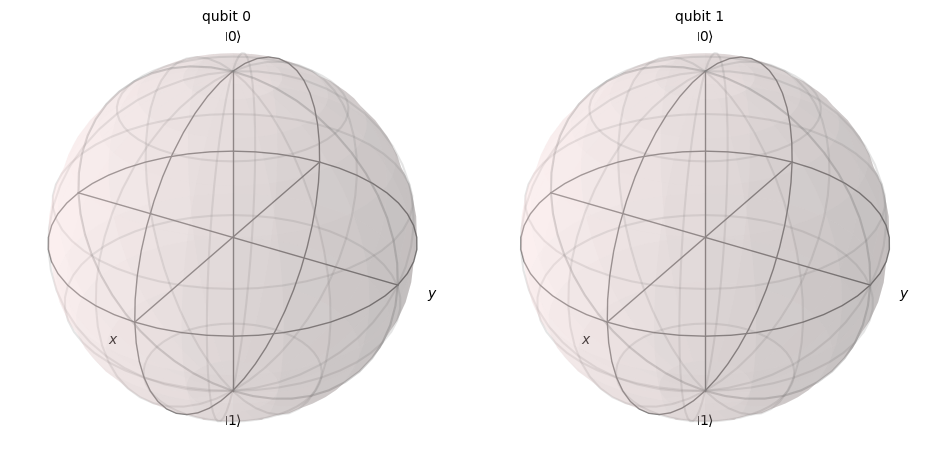

In [32]:
fig = plot_bloch_multivector(bell_state)
display(fig)

New circuit created!


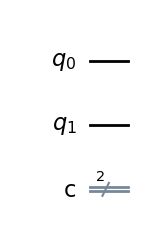

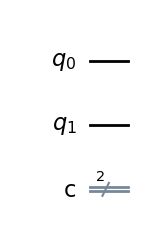

In [33]:
qc_app = QuantumCircuit(2, 2)

print("New circuit created!")
display(qc_app.draw("mpl"))

In [34]:
gate_dropdown = widgets.Dropdown(
    options=[
        "X",
        "Y",
        "Z",
        "H",
        "S",
        "T",
        "RX",
        "RY",
        "RZ"
    ],
    value="H",
    description="Gate:"
)

qubit_dropdown = widgets.Dropdown(
    options=[0, 1],
    value=0,
    description="Qubit:"
)

angle_slider = widgets.FloatSlider(
    value=0,
    min=-np.pi,
    max=np.pi,
    step=0.1,
    description="Angle:",
    readout_format=".2f"
)

add_gate_button = widgets.Button(
    description="Add Gate",
    button_style="success"
)

reset_button = widgets.Button(
    description="Reset",
    button_style="warning"
)

simulate_button = widgets.Button(
    description="Simulate",
    button_style="primary"
)

print("Controls created!")

Controls created!


In [35]:
display(
    gate_dropdown,
    qubit_dropdown,
    angle_slider,
    add_gate_button,
    reset_button,
    simulate_button
)

Dropdown(description='Gate:', index=3, options=('X', 'Y', 'Z', 'H', 'S', 'T', 'RX', 'RY', 'RZ'), value='H')

Dropdown(description='Qubit:', options=(0, 1), value=0)

FloatSlider(value=0.0, description='Angle:', max=3.141592653589793, min=-3.141592653589793)

Button(button_style='success', description='Add Gate', style=ButtonStyle())

Button(button_style='warning', description='Reset', style=ButtonStyle())

Button(button_style='primary', description='Simulate', style=ButtonStyle())

In [36]:
output = widgets.Output()

display(output)

Output()

In [37]:
def add_gate_clicked(b):
    gate = gate_dropdown.value
    qubit = qubit_dropdown.value
    angle = angle_slider.value

    if gate == "X":
        qc_app.x(qubit)

    elif gate == "Y":
        qc_app.y(qubit)

    elif gate == "Z":
        qc_app.z(qubit)

    elif gate == "H":
        qc_app.h(qubit)

    elif gate == "S":
        qc_app.s(qubit)

    elif gate == "T":
        qc_app.t(qubit)

    elif gate == "RX":
        qc_app.rx(angle, qubit)

    elif gate == "RY":
        qc_app.ry(angle, qubit)

    elif gate == "RZ":
        qc_app.rz(angle, qubit)

    with output:
        clear_output(wait=True)
        print("Current Circuit:")
        display(qc_app.draw("mpl"))


add_gate_button.on_click(add_gate_clicked)

In [38]:
def reset_clicked(b):
    global qc_app

    qc_app = QuantumCircuit(2, 2)

    with output:
        clear_output(wait=True)
        print("Circuit reset.")
        display(qc_app.draw("mpl"))


reset_button.on_click(reset_clicked)

In [39]:
def simulate_clicked(b):
    measured_circuit = qc_app.copy()

    measured_circuit.measure_all()

    simulator = AerSimulator()

    result = simulator.run(
        measured_circuit,
        shots=1024
    ).result()

    counts = result.get_counts()

    with output:
        clear_output(wait=True)

        print("Circuit:")
        display(qc_app.draw("mpl"))

        print("\nMeasurement Results:")
        print(counts)

        print("\nHistogram:")

        fig = plot_histogram(counts)
        display(fig)


simulate_button.on_click(simulate_clicked)